  # **Predictive Maintenance — AI4I 2020 Dataset**



\# **PHASE** 1 — Setup & **Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc,
    f1_score, precision_score, recall_score, accuracy_score,
    matthews_corrcoef, precision_recall_curve, average_precision_score
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Boosting
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import tensorflow as tf

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('All libraries loaded successfully.')

All libraries loaded successfully.


  PHASE 2 —  **Load Dataset**


In [2]:

# Load the AI4I 2020 dataset
df = pd.read_csv("../ai4i2020.csv")
df.head()

# Show shape and first rows
print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head(10)

# Column info
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistical Summary ===')
df.describe().round(3)

# Column names and unique values
for col in df.columns:
    print(f'{col:35s} | dtype: {str(df[col].dtype):10s} | unique: {df[col].nunique()}')




Dataset shape: (10000, 14)
Rows: 10,000 | Columns: 14
=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF          

#  PHASE 3 — Exploratory Data Analysis (EDA)


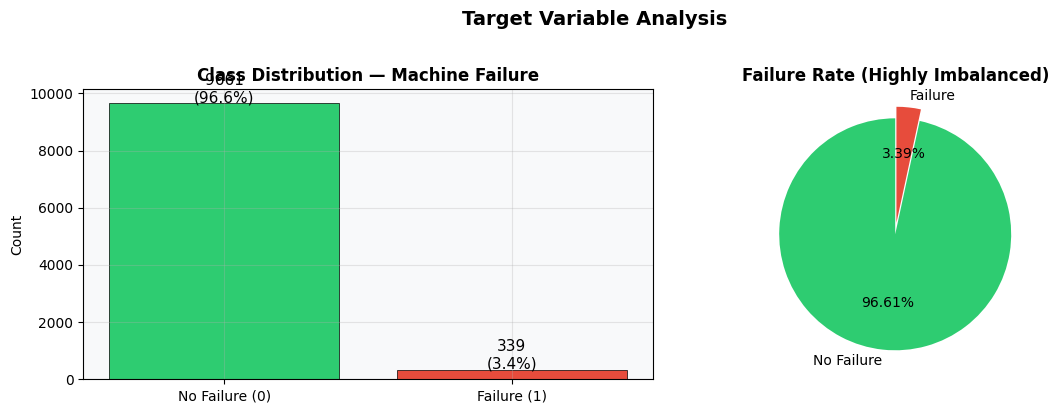

Class imbalance ratio: 28.5:1  (Non-failure : Failure)


In [3]:
# Target class distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Machine failure'].value_counts()
axes[0].bar(['No Failure (0)', 'Failure (1)'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Class Distribution — Machine Failure', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=['No Failure', 'Failure'],
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Failure Rate (Highly Imbalanced)', fontweight='bold')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Class imbalance ratio: {counts[0]/counts[1]:.1f}:1  (Non-failure : Failure)')

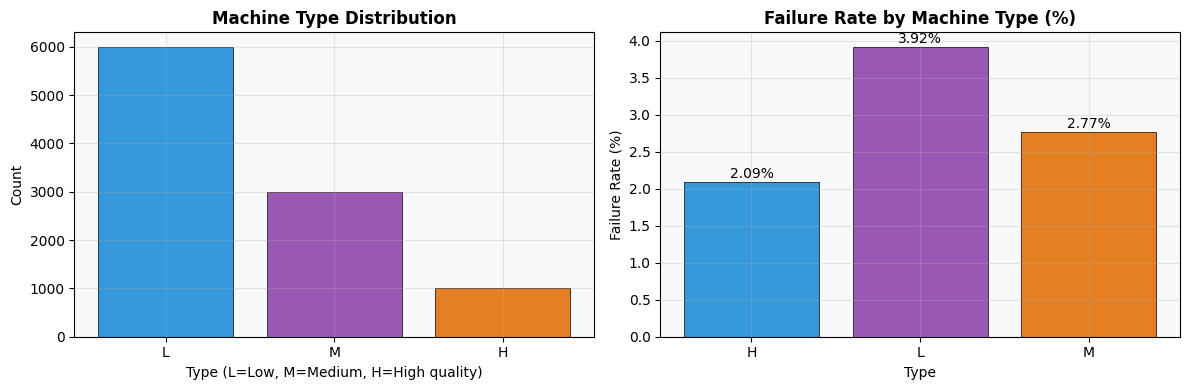

In [4]:
#  Machine Type distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_counts = df['Type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values,
            color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Machine Type Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Type (L=Low, M=Medium, H=High quality)')

# Failure rate per type
fail_rate = df.groupby('Type')['Machine failure'].mean() * 100
axes[1].bar(fail_rate.index, fail_rate.values,
            color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Failure Rate by Machine Type (%)', fontweight='bold')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_xlabel('Type')
for i, (idx, val) in enumerate(fail_rate.items()):
    axes[1].text(i, val + 0.05, f'{val:.2f}%', ha='center')

plt.tight_layout()
plt.show()



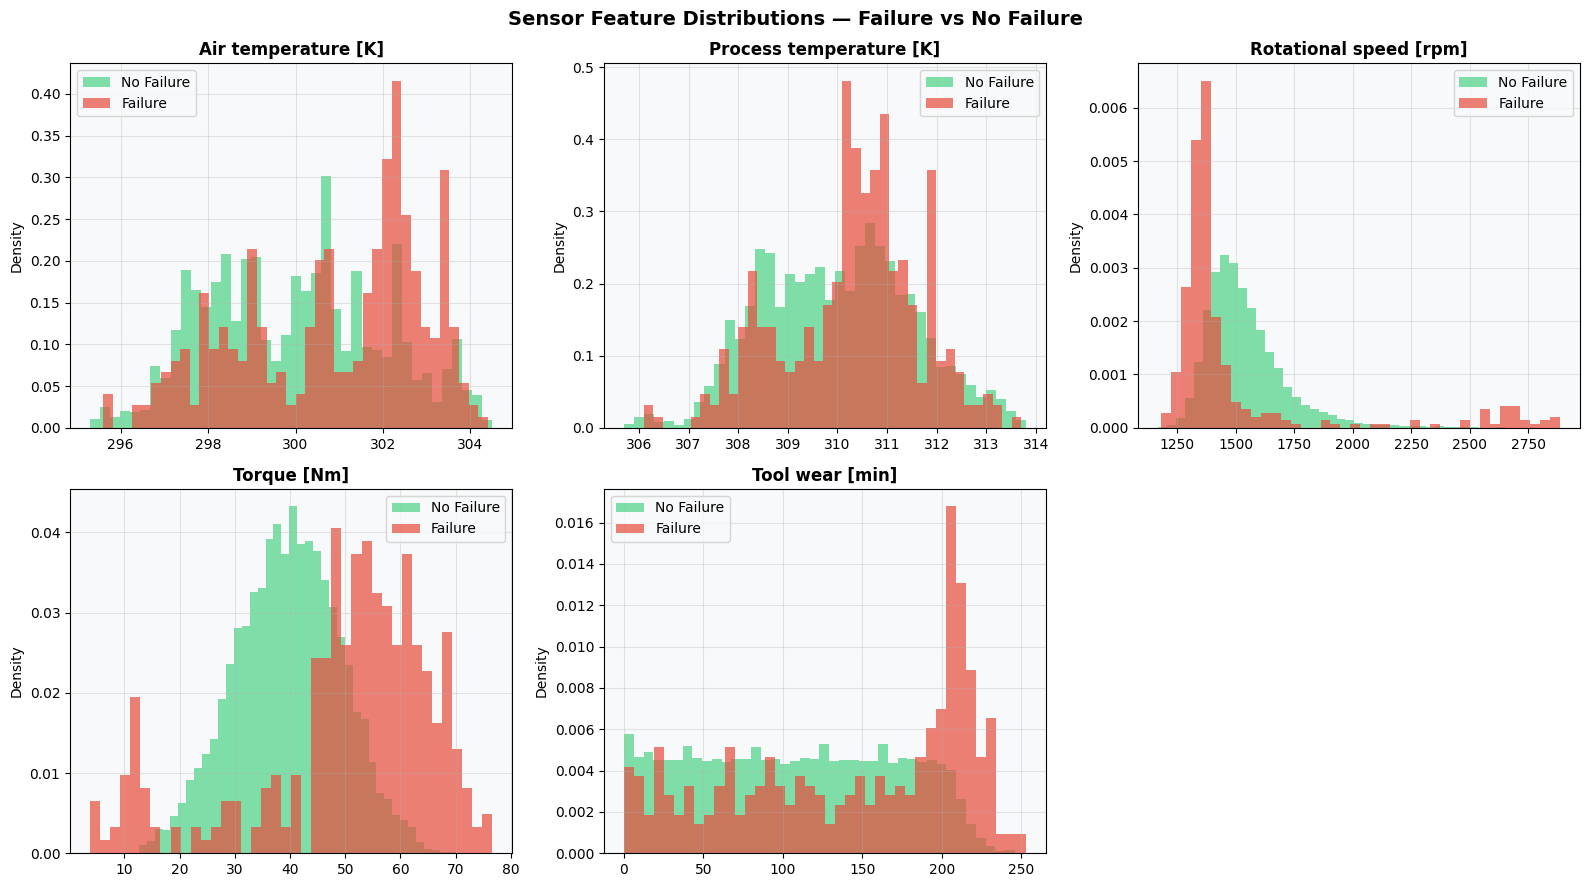

In [5]:
#  Sensor feature distributions — split by failure label
sensor_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(sensor_features):
    axes[i].hist(df[df['Machine failure']==0][feat], bins=40, alpha=0.6,
                 color='#2ecc71', label='No Failure', density=True)
    axes[i].hist(df[df['Machine failure']==1][feat], bins=40, alpha=0.7,
                 color='#e74c3c', label='Failure', density=True)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_ylabel('Density')
    axes[i].legend()

axes[5].axis('off')
plt.suptitle('Sensor Feature Distributions — Failure vs No Failure',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



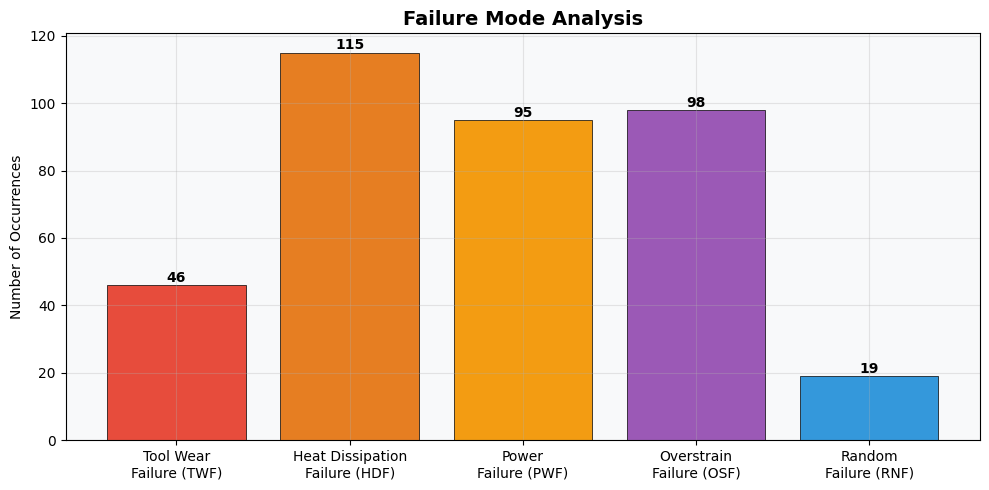

In [6]:
# Failure type breakdown
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_labels = [
    'Tool Wear\nFailure (TWF)',
    'Heat Dissipation\nFailure (HDF)',
    'Power\nFailure (PWF)',
    'Overstrain\nFailure (OSF)',
    'Random\nFailure (RNF)'
]
failure_counts = df[failure_types].sum().values

plt.figure(figsize=(10, 5))
bars = plt.bar(failure_labels, failure_counts,
               color=['#e74c3c','#e67e22','#f39c12','#9b59b6','#3498db'],
               edgecolor='black', linewidth=0.5)
plt.title('Failure Mode Analysis', fontsize=14, fontweight='bold')
plt.ylabel('Number of Occurrences')
for bar, val in zip(bars, failure_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



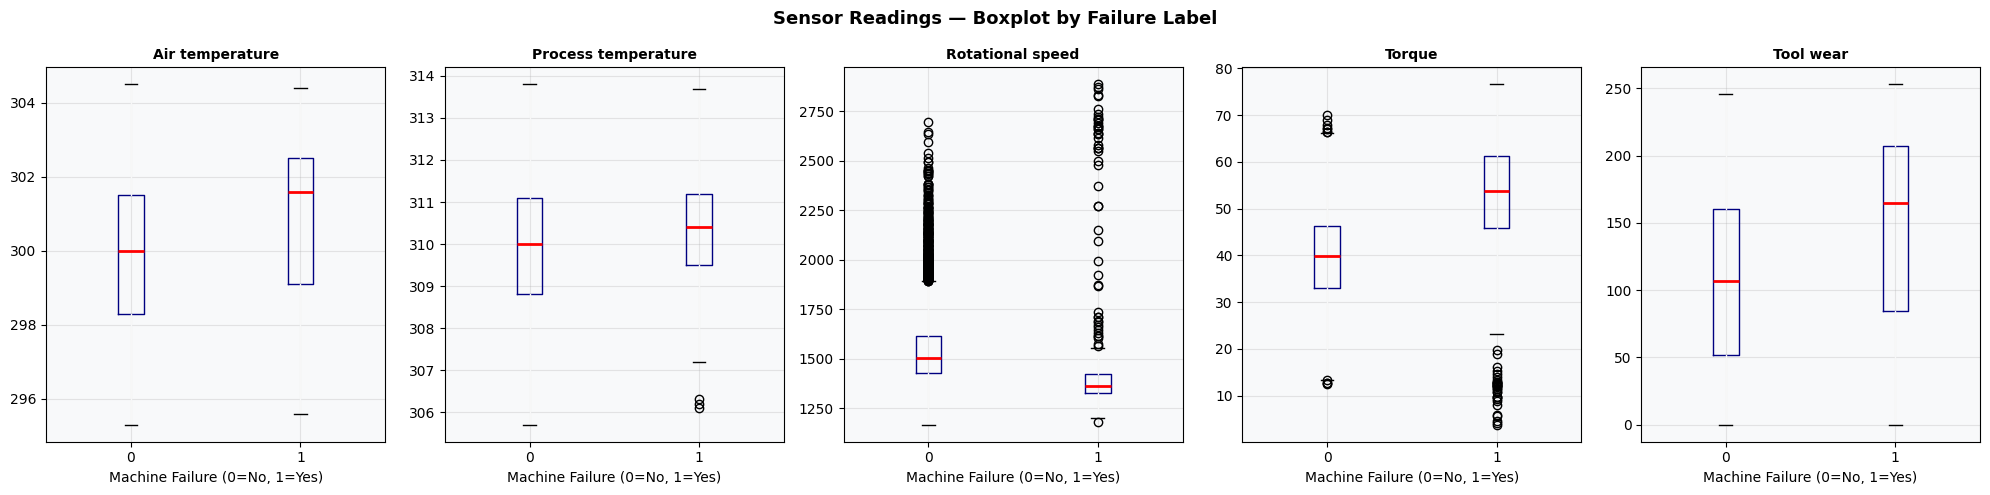

In [7]:
# Boxplots — sensor features vs failure
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, feat in enumerate(sensor_features):
    df.boxplot(column=feat, by='Machine failure', ax=axes[i],
               boxprops=dict(color='navy'),
               medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(feat.split('[')[0].strip(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Machine Failure (0=No, 1=Yes)')

plt.suptitle('Sensor Readings — Boxplot by Failure Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()



# PHASE 4 — Preprocessing & Feature Engineering

In [8]:
# ============================================================
# DATA PREPARATION
# ============================================================

# Create a copy of the dataset
df_processed = df.copy()

# Encode machine type
le = LabelEncoder()

df_processed['Type_enc'] = le.fit_transform(
    df_processed['Type']
)

# Select original features
feature_cols = [
    'Type_enc',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Create feature matrix
X = df_processed[feature_cols]

# Create target vector
y = df_processed['Machine failure']

print("Feature Matrix Shape:", X.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Feature Matrix Shape: (10000, 6)

Target Distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [9]:
# ============================================================
# HANDLE CLASS IMBALANCE USING SMOTE FIRST
# ============================================================

smote = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_resampled, y_resampled = smote.fit_resample(
    X,
    y
)

print("\nClass Distribution:")

print("Before SMOTE:")
print(dict(y.value_counts()))

print("\nAfter SMOTE:")
print(dict(pd.Series(y_resampled).value_counts()))

# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.15,
    random_state=42,
    stratify=y_resampled
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.176,
    random_state=42,
    stratify=y_train_full
)

print("\nDataset Split:")

print(f"Train Samples      : {len(X_train):,}")
print(f"Validation Samples : {len(X_val):,}")
print(f"Test Samples       : {len(X_test):,}")

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)

X_val_sc = scaler.transform(X_val)

X_test_sc = scaler.transform(X_test)

print("\nScaling Completed")

print(f"Training Mean ≈ {X_train_sc.mean():.4f}")
print(f"Training Std ≈ {X_train_sc.std():.4f}")


Class Distribution:
Before SMOTE:
{0: np.int64(9661), 1: np.int64(339)}

After SMOTE:
{0: np.int64(9661), 1: np.int64(9661)}

Dataset Split:
Train Samples      : 13,532
Validation Samples : 2,891
Test Samples       : 2,899

Scaling Completed
Training Mean ≈ 0.0000
Training Std ≈ 1.0000



Feature Importance Ranking:


,Feature,Importance
4,Torque [Nm],0.314620
3,Rotational speed [rpm],0.287997
5,Tool wear [min],0.204921
1,Air temperature [K],0.089060
2,Process temperature [K],0.062240
0,Type_enc,0.041161


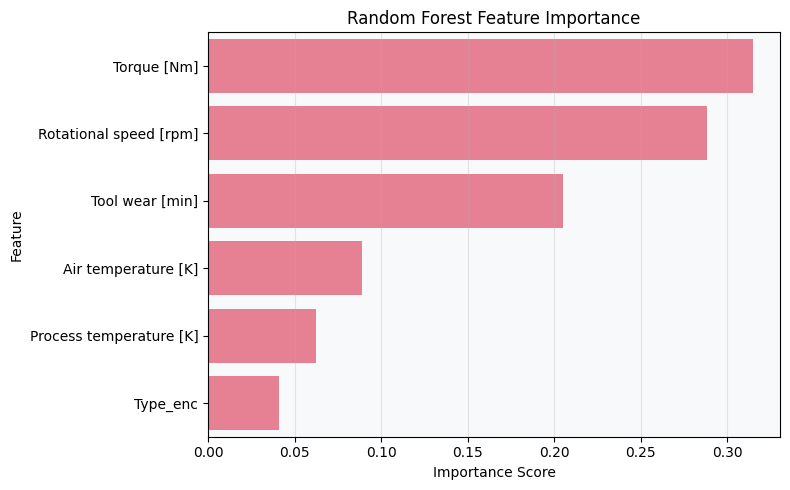

In [10]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Train temporary Random Forest model
rf_importance = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_importance.fit(
    X_train,
    y_train
)

# Extract feature importance scores
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_importance.feature_importances_
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance Ranking:")
display(importance_df)

# Visualize importance
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

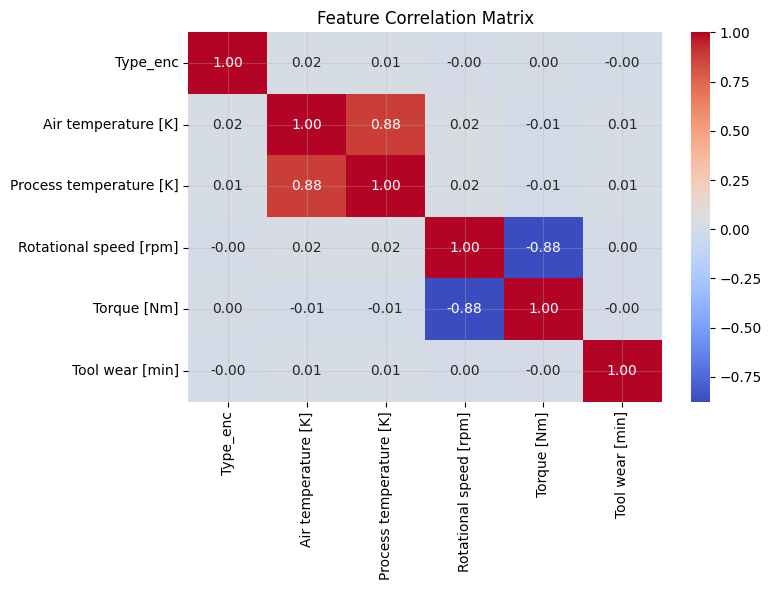


High correlation (>0.80) may indicate redundant information between features.


In [11]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

# Calculate correlation matrix
corr_matrix = X.corr()

# Plot correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print(
    "\nHigh correlation (>0.80) may indicate "
    "redundant information between features."
)

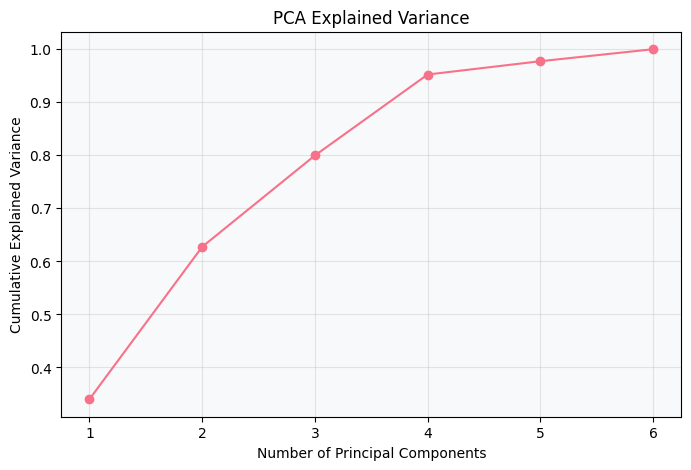


Explained Variance Ratio:
[0.34014289 0.28734544 0.17219465 0.15262033 0.02509417 0.02260251]


In [12]:
# ============================================================
# PCA ANALYSIS
# ============================================================

from sklearn.decomposition import PCA

# Apply PCA to scaled training data
pca = PCA()

pca.fit(X_train_sc)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

# Plot cumulative variance
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')

plt.title('PCA Explained Variance')

plt.grid(True)

plt.show()

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

In [13]:
# ============================================================
# REDUCED FEATURE DATASET PREPARATION (OLD PIPELINE)
# ============================================================

# Based on Feature Importance and Correlation Analysis:
# Removed:
# 1. Type_enc
# 2. Process temperature [K]

reduced_feature_cols = [
    'Air temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

# Create reduced feature matrix
X_reduced = df_processed[reduced_feature_cols]

# Target
y_reduced = df_processed['Machine failure']

print("Selected Reduced Features:")

for feature in reduced_feature_cols:
    print("-", feature)

print(f"\nReduced Feature Matrix Shape: {X_reduced.shape}")

# ============================================================
# SMOTE FIRST (OLD WORKFLOW)
# ============================================================

smote_red = SMOTE(
    random_state=42,
    k_neighbors=5
)

X_resampled_red, y_resampled_red = smote_red.fit_resample(
    X_reduced,
    y_reduced
)

print("\nClass Distribution")

print("Before SMOTE:")
print(dict(y_reduced.value_counts()))

print("\nAfter SMOTE:")
print(dict(pd.Series(y_resampled_red).value_counts()))

print(
    f"\nTotal Samples After SMOTE: "
    f"{len(X_resampled_red):,}"
)

# ============================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================

X_train_full_red, X_test_red, y_train_full_red, y_test_red = train_test_split(
    X_resampled_red,
    y_resampled_red,
    test_size=0.15,
    random_state=42,
    stratify=y_resampled_red
)

X_train_red, X_val_red, y_train_red, y_val_red = train_test_split(
    X_train_full_red,
    y_train_full_red,
    test_size=0.176,
    random_state=42,
    stratify=y_train_full_red
)

print("\nDataset Split:")

print(f"Train Samples      : {len(X_train_red):,}")
print(f"Validation Samples : {len(X_val_red):,}")
print(f"Test Samples       : {len(X_test_red):,}")

# ============================================================
# FEATURE SCALING
# ============================================================

scaler_red = StandardScaler()

X_train_sc_red = scaler_red.fit_transform(
    X_train_red
)

X_val_sc_red = scaler_red.transform(
    X_val_red
)

X_test_sc_red = scaler_red.transform(
    X_test_red
)

print("\nScaling Completed")

print(
    f"Training Mean ≈ {X_train_sc_red.mean():.4f}"
)

print(
    f"Training Std ≈ {X_train_sc_red.std():.4f}"
)

print("\nReduced Dataset Ready For Training")

print(
    f"Training Shape   : {X_train_sc_red.shape}"
)

print(
    f"Validation Shape : {X_val_sc_red.shape}"
)

print(
    f"Test Shape       : {X_test_sc_red.shape}"
)

Selected Reduced Features:
- Air temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]

Reduced Feature Matrix Shape: (10000, 4)

Class Distribution
Before SMOTE:
{0: np.int64(9661), 1: np.int64(339)}

After SMOTE:
{0: np.int64(9661), 1: np.int64(9661)}

Total Samples After SMOTE: 19,322

Dataset Split:
Train Samples      : 13,532
Validation Samples : 2,891
Test Samples       : 2,899

Scaling Completed
Training Mean ≈ -0.0000
Training Std ≈ 1.0000

Reduced Dataset Ready For Training
Training Shape   : (13532, 4)
Validation Shape : (2891, 4)
Test Shape       : (2899, 4)


#  PHASE 5 — Baseline ML Models

In [14]:
print("Original:")
print(X_train_sc.shape)
print(y_train.shape)

print("\nReduced:")
print(X_train_sc_red.shape)
print(y_train_red.shape)

print("\nOriginal class distribution:")
print(pd.Series(y_train).value_counts())

print("\nReduced class distribution:")
print(pd.Series(y_train_red).value_counts())

Original:
(13532, 6)
(13532,)

Reduced:
(13532, 4)
(13532,)

Original class distribution:
Machine failure
1    6766
0    6766
Name: count, dtype: int64

Reduced class distribution:
Machine failure
1    6766
0    6766
Name: count, dtype: int64


In [15]:
print("Original Test Distribution")
print(y_test.value_counts())

print("\nReduced Test Distribution")
print(y_test_red.value_counts())

Original Test Distribution
Machine failure
0    1450
1    1449
Name: count, dtype: int64

Reduced Test Distribution
Machine failure
0    1450
1    1449
Name: count, dtype: int64


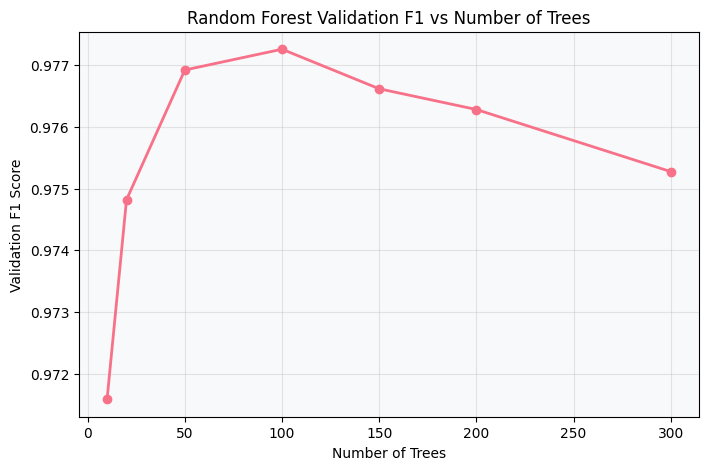


Random Forest Results


,Dataset,Validation Accuracy,Validation F1,Validation AUC,Test Accuracy,Test F1,Test AUC
0,Original Features,0.977171,0.977257,0.997648,0.974819,0.975179,0.997699
1,Reduced Features,0.967485,0.967896,0.993481,0.969645,0.970169,0.995972


In [16]:
# ============================================================
# RANDOM FOREST ANALYSIS
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# ORIGINAL FEATURES MODEL
# ============================================================

rf_original = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_original.fit(
    X_train_sc,
    y_train
)

# Validation predictions
val_pred_original = rf_original.predict(X_val_sc)

# Test predictions
test_pred_original = rf_original.predict(X_test_sc)

# Probabilities
val_prob_original = rf_original.predict_proba(X_val_sc)[:,1]
test_prob_original = rf_original.predict_proba(X_test_sc)[:,1]

# ============================================================
# REDUCED FEATURES MODEL
# ============================================================

rf_reduced = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_reduced.fit(
    X_train_sc_red,
    y_train_red
)

# Validation predictions
val_pred_reduced = rf_reduced.predict(X_val_sc_red)

# Test predictions
test_pred_reduced = rf_reduced.predict(X_test_sc_red)

# Probabilities
val_prob_reduced = rf_reduced.predict_proba(X_val_sc_red)[:,1]
test_prob_reduced = rf_reduced.predict_proba(X_test_sc_red)[:,1]

# ============================================================
# TRAINING / COMPLEXITY CURVE
# ============================================================

tree_counts = [10,20,50,100,150,200,300]

val_f1_scores = []

for n in tree_counts:

    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train_sc,
        y_train
    )

    pred = model.predict(X_val_sc)

    val_f1_scores.append(
        f1_score(y_val, pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    tree_counts,
    val_f1_scores,
    marker='o',
    linewidth=2
)

plt.title(
    'Random Forest Validation F1 vs Number of Trees'
)

plt.xlabel('Number of Trees')
plt.ylabel('Validation F1 Score')

plt.grid(True)

plt.show()

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison_rf = pd.DataFrame({

    'Dataset': [
        'Original Features',
        'Reduced Features'
    ],

    'Validation Accuracy': [
        accuracy_score(y_val, val_pred_original),
        accuracy_score(y_val_red, val_pred_reduced)
    ],

    'Validation F1': [
        f1_score(y_val, val_pred_original),
        f1_score(y_val_red, val_pred_reduced)
    ],

    'Validation AUC': [
        roc_auc_score(y_val, val_prob_original),
        roc_auc_score(y_val_red, val_prob_reduced)
    ],

    'Test Accuracy': [
        accuracy_score(y_test, test_pred_original),
        accuracy_score(y_test_red, test_pred_reduced)
    ],

    'Test F1': [
        f1_score(y_test, test_pred_original),
        f1_score(y_test_red, test_pred_reduced)
    ],

    'Test AUC': [
        roc_auc_score(y_test, test_prob_original),
        roc_auc_score(y_test_red, test_prob_reduced)
    ]
})

print("\nRandom Forest Results")
display(comparison_rf)

rf_result = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, test_pred_original),
    "Precision": precision_score(y_test, test_pred_original),
    "Recall": recall_score(y_test, test_pred_original),
    "F1": f1_score(y_test, test_pred_original),
    "AUC": roc_auc_score(y_test, test_prob_original)
}

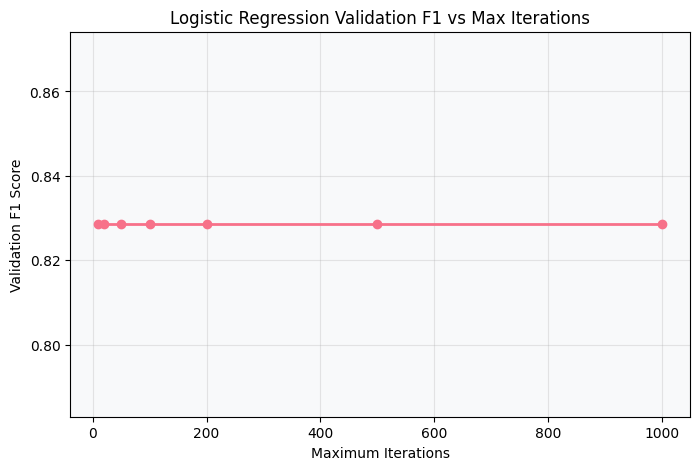


Logistic Regression Results


,Dataset,Validation Accuracy,Validation F1,Validation AUC,Test Accuracy,Test F1,Test AUC
0,Original Features,0.828087,0.828562,0.913918,0.835805,0.834607,0.915351
1,Reduced Features,0.812522,0.811281,0.897780,0.813039,0.812327,0.897673


In [17]:
# ============================================================
# LOGISTIC REGRESSION ANALYSIS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# ORIGINAL FEATURES MODEL
# ============================================================

lr_original = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_original.fit(
    X_train_sc,
    y_train
)

# Validation predictions
val_pred_original = lr_original.predict(X_val_sc)

# Test predictions
test_pred_original = lr_original.predict(X_test_sc)

# Prediction probabilities
val_prob_original = lr_original.predict_proba(X_val_sc)[:,1]
test_prob_original = lr_original.predict_proba(X_test_sc)[:,1]

# ============================================================
# REDUCED FEATURES MODEL
# ============================================================

lr_reduced = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_reduced.fit(
    X_train_sc_red,
    y_train_red
)

# Validation predictions
val_pred_reduced = lr_reduced.predict(X_val_sc_red)

# Test predictions
test_pred_reduced = lr_reduced.predict(X_test_sc_red)

# Prediction probabilities
val_prob_reduced = lr_reduced.predict_proba(X_val_sc_red)[:,1]
test_prob_reduced = lr_reduced.predict_proba(X_test_sc_red)[:,1]

# ============================================================
# TRAINING / COMPLEXITY CURVE
# ============================================================

iteration_values = [10,20,50,100,200,500,1000]

val_f1_scores = []

for n in iteration_values:

    model = LogisticRegression(
        max_iter=n,
        random_state=42
    )

    model.fit(
        X_train_sc,
        y_train
    )

    pred = model.predict(X_val_sc)

    val_f1_scores.append(
        f1_score(y_val, pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    iteration_values,
    val_f1_scores,
    marker='o',
    linewidth=2
)

plt.title(
    'Logistic Regression Validation F1 vs Max Iterations'
)

plt.xlabel('Maximum Iterations')
plt.ylabel('Validation F1 Score')

plt.grid(True)

plt.show()

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison_lr = pd.DataFrame({

    'Dataset': [
        'Original Features',
        'Reduced Features'
    ],

    'Validation Accuracy': [
        accuracy_score(y_val, val_pred_original),
        accuracy_score(y_val_red, val_pred_reduced)
    ],

    'Validation F1': [
        f1_score(y_val, val_pred_original),
        f1_score(y_val_red, val_pred_reduced)
    ],

    'Validation AUC': [
        roc_auc_score(y_val, val_prob_original),
        roc_auc_score(y_val_red, val_prob_reduced)
    ],

    'Test Accuracy': [
        accuracy_score(y_test, test_pred_original),
        accuracy_score(y_test_red, test_pred_reduced)
    ],

    'Test F1': [
        f1_score(y_test, test_pred_original),
        f1_score(y_test_red, test_pred_reduced)
    ],

    'Test AUC': [
        roc_auc_score(y_test, test_prob_original),
        roc_auc_score(y_test_red, test_prob_reduced)
    ]
})

print("\nLogistic Regression Results")
display(comparison_lr)

lr_result = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, test_pred_original),
    "Precision": precision_score(y_test, test_pred_original),
    "Recall": recall_score(y_test, test_pred_original),
    "F1": f1_score(y_test, test_pred_original),
    "AUC": roc_auc_score(y_test, test_prob_original)
}

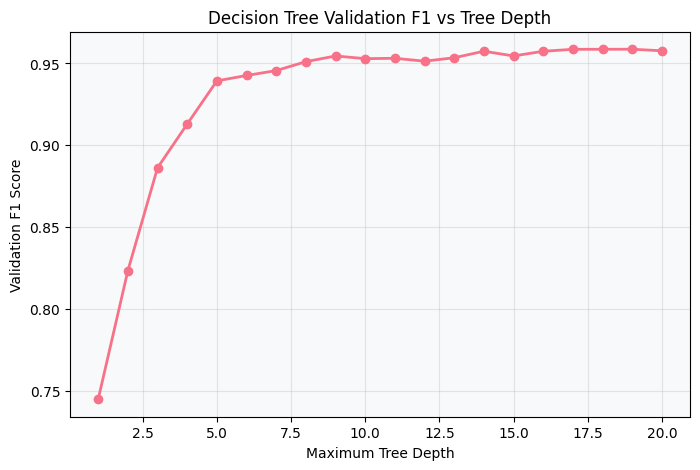


Decision Tree Results


,Dataset,Validation Accuracy,Validation F1,Validation AUC,Test Accuracy,Test F1,Test AUC
0,Original Features,0.958492,0.958706,0.958490,0.962056,0.962329,0.962058
1,Reduced Features,0.952266,0.952675,0.952263,0.954467,0.954608,0.954468


In [18]:
# ============================================================
# DECISION TREE ANALYSIS
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# ORIGINAL FEATURES MODEL
# ============================================================

dt_original = DecisionTreeClassifier(
    random_state=42
)

dt_original.fit(
    X_train_sc,
    y_train
)

# Validation predictions
val_pred_original = dt_original.predict(X_val_sc)

# Test predictions
test_pred_original = dt_original.predict(X_test_sc)

# Prediction probabilities
val_prob_original = dt_original.predict_proba(X_val_sc)[:,1]
test_prob_original = dt_original.predict_proba(X_test_sc)[:,1]

# ============================================================
# REDUCED FEATURES MODEL
# ============================================================

dt_reduced = DecisionTreeClassifier(
    random_state=42
)

dt_reduced.fit(
    X_train_sc_red,
    y_train_red
)

# Validation predictions
val_pred_reduced = dt_reduced.predict(X_val_sc_red)

# Test predictions
test_pred_reduced = dt_reduced.predict(X_test_sc_red)

# Prediction probabilities
val_prob_reduced = dt_reduced.predict_proba(X_val_sc_red)[:,1]
test_prob_reduced = dt_reduced.predict_proba(X_test_sc_red)[:,1]

# ============================================================
# TRAINING / COMPLEXITY CURVE
# ============================================================

depth_values = range(1,21)

val_f1_scores = []

for depth in depth_values:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(
        X_train_sc,
        y_train
    )

    pred = model.predict(X_val_sc)

    val_f1_scores.append(
        f1_score(y_val, pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    depth_values,
    val_f1_scores,
    marker='o',
    linewidth=2
)

plt.title(
    'Decision Tree Validation F1 vs Tree Depth'
)

plt.xlabel('Maximum Tree Depth')
plt.ylabel('Validation F1 Score')

plt.grid(True)

plt.show()

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison_dt = pd.DataFrame({

    'Dataset': [
        'Original Features',
        'Reduced Features'
    ],

    'Validation Accuracy': [
        accuracy_score(y_val, val_pred_original),
        accuracy_score(y_val_red, val_pred_reduced)
    ],

    'Validation F1': [
        f1_score(y_val, val_pred_original),
        f1_score(y_val_red, val_pred_reduced)
    ],

    'Validation AUC': [
        roc_auc_score(y_val, val_prob_original),
        roc_auc_score(y_val_red, val_prob_reduced)
    ],

    'Test Accuracy': [
        accuracy_score(y_test, test_pred_original),
        accuracy_score(y_test_red, test_pred_reduced)
    ],

    'Test F1': [
        f1_score(y_test, test_pred_original),
        f1_score(y_test_red, test_pred_reduced)
    ],

    'Test AUC': [
        roc_auc_score(y_test, test_prob_original),
        roc_auc_score(y_test_red, test_prob_reduced)
    ]
})

print("\nDecision Tree Results")
display(comparison_dt)

dt_result = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, test_pred_original),
    "Precision": precision_score(y_test, test_pred_original),
    "Recall": recall_score(y_test, test_pred_original),
    "F1": f1_score(y_test, test_pred_original),
    "AUC": roc_auc_score(y_test, test_prob_original)
}

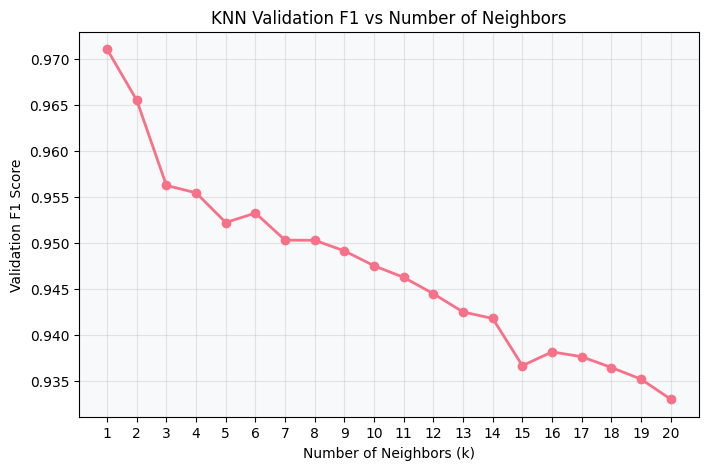


K-Nearest Neighbors Results


,Dataset,Validation Accuracy,Validation F1,Validation AUC,Test Accuracy,Test F1,Test AUC
0,Original Features,0.950882,0.952221,0.982382,0.955157,0.956551,0.981935
1,Reduced Features,0.942926,0.944982,0.974853,0.941359,0.943409,0.977053


In [19]:
# ============================================================
# K-NEAREST NEIGHBORS (KNN) ANALYSIS
# ============================================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# ORIGINAL FEATURES MODEL
# ============================================================

knn_original = KNeighborsClassifier(
    n_neighbors=5
)

knn_original.fit(
    X_train_sc,
    y_train
)

# Validation predictions
val_pred_original = knn_original.predict(X_val_sc)

# Test predictions
test_pred_original = knn_original.predict(X_test_sc)

# Prediction probabilities
val_prob_original = knn_original.predict_proba(X_val_sc)[:,1]
test_prob_original = knn_original.predict_proba(X_test_sc)[:,1]

# ============================================================
# REDUCED FEATURES MODEL
# ============================================================

knn_reduced = KNeighborsClassifier(
    n_neighbors=5
)

knn_reduced.fit(
    X_train_sc_red,
    y_train_red
)

# Validation predictions
val_pred_reduced = knn_reduced.predict(X_val_sc_red)

# Test predictions
test_pred_reduced = knn_reduced.predict(X_test_sc_red)

# Prediction probabilities
val_prob_reduced = knn_reduced.predict_proba(X_val_sc_red)[:,1]
test_prob_reduced = knn_reduced.predict_proba(X_test_sc_red)[:,1]

# ============================================================
# TRAINING / COMPLEXITY CURVE
# ============================================================

k_values = range(1,21)

val_f1_scores = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_sc,
        y_train
    )

    pred = model.predict(X_val_sc)

    val_f1_scores.append(
        f1_score(y_val, pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    val_f1_scores,
    marker='o',
    linewidth=2
)

plt.title(
    'KNN Validation F1 vs Number of Neighbors'
)

plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Validation F1 Score')

plt.xticks(k_values)

plt.grid(True)

plt.show()

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison_knn = pd.DataFrame({

    'Dataset': [
        'Original Features',
        'Reduced Features'
    ],

    'Validation Accuracy': [
        accuracy_score(y_val, val_pred_original),
        accuracy_score(y_val_red, val_pred_reduced)
    ],

    'Validation F1': [
        f1_score(y_val, val_pred_original),
        f1_score(y_val_red, val_pred_reduced)
    ],

    'Validation AUC': [
        roc_auc_score(y_val, val_prob_original),
        roc_auc_score(y_val_red, val_prob_reduced)
    ],

    'Test Accuracy': [
        accuracy_score(y_test, test_pred_original),
        accuracy_score(y_test_red, test_pred_reduced)
    ],

    'Test F1': [
        f1_score(y_test, test_pred_original),
        f1_score(y_test_red, test_pred_reduced)
    ],

    'Test AUC': [
        roc_auc_score(y_test, test_prob_original),
        roc_auc_score(y_test_red, test_prob_reduced)
    ]
})

print("\nK-Nearest Neighbors Results")
display(comparison_knn)


knn_result = {
    "Model": "KNN",
    "Accuracy": accuracy_score(y_test, test_pred_original),
    "Precision": precision_score(y_test, test_pred_original),
    "Recall": recall_score(y_test, test_pred_original),
    "F1": f1_score(y_test, test_pred_original),
    "AUC": roc_auc_score(y_test, test_prob_original)
}

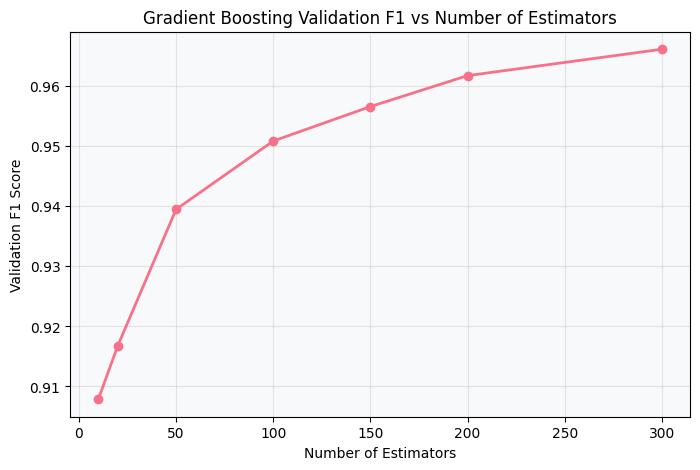


Gradient Boosting Results


,Dataset,Validation Accuracy,Validation F1,Validation AUC,Test Accuracy,Test F1,Test AUC
0,Original Features,0.950536,0.950876,0.988391,0.946188,0.947333,0.987038
1,Reduced Features,0.939813,0.940816,0.982396,0.940669,0.942127,0.981356


In [20]:
# ============================================================
# GRADIENT BOOSTING ANALYSIS
# ============================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# ORIGINAL FEATURES MODEL
# ============================================================

gb_original = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_original.fit(
    X_train_sc,
    y_train
)

# Validation predictions
val_pred_original = gb_original.predict(X_val_sc)

# Test predictions
test_pred_original = gb_original.predict(X_test_sc)

# Prediction probabilities
val_prob_original = gb_original.predict_proba(X_val_sc)[:,1]
test_prob_original = gb_original.predict_proba(X_test_sc)[:,1]

# ============================================================
# REDUCED FEATURES MODEL
# ============================================================

gb_reduced = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb_reduced.fit(
    X_train_sc_red,
    y_train_red
)

# Validation predictions
val_pred_reduced = gb_reduced.predict(X_val_sc_red)

# Test predictions
test_pred_reduced = gb_reduced.predict(X_test_sc_red)

# Prediction probabilities
val_prob_reduced = gb_reduced.predict_proba(X_val_sc_red)[:,1]
test_prob_reduced = gb_reduced.predict_proba(X_test_sc_red)[:,1]

# ============================================================
# TRAINING / COMPLEXITY CURVE
# ============================================================

estimator_values = [10,20,50,100,150,200,300]

val_f1_scores = []

for n in estimator_values:

    model = GradientBoostingClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(
        X_train_sc,
        y_train
    )

    pred = model.predict(X_val_sc)

    val_f1_scores.append(
        f1_score(y_val, pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    estimator_values,
    val_f1_scores,
    marker='o',
    linewidth=2
)

plt.title(
    'Gradient Boosting Validation F1 vs Number of Estimators'
)

plt.xlabel('Number of Estimators')
plt.ylabel('Validation F1 Score')

plt.grid(True)

plt.show()

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison_gb = pd.DataFrame({

    'Dataset': [
        'Original Features',
        'Reduced Features'
    ],

    'Validation Accuracy': [
        accuracy_score(y_val, val_pred_original),
        accuracy_score(y_val_red, val_pred_reduced)
    ],

    'Validation F1': [
        f1_score(y_val, val_pred_original),
        f1_score(y_val_red, val_pred_reduced)
    ],

    'Validation AUC': [
        roc_auc_score(y_val, val_prob_original),
        roc_auc_score(y_val_red, val_prob_reduced)
    ],

    'Test Accuracy': [
        accuracy_score(y_test, test_pred_original),
        accuracy_score(y_test_red, test_pred_reduced)
    ],

    'Test F1': [
        f1_score(y_test, test_pred_original),
        f1_score(y_test_red, test_pred_reduced)
    ],

    'Test AUC': [
        roc_auc_score(y_test, test_prob_original),
        roc_auc_score(y_test_red, test_prob_reduced)
    ]
})

print("\nGradient Boosting Results")
display(comparison_gb)

gb_result = {
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_test, test_pred_original),
    "Precision": precision_score(y_test, test_pred_original),
    "Recall": recall_score(y_test, test_pred_original),
    "F1": f1_score(y_test, test_pred_original),
    "AUC": roc_auc_score(y_test, test_prob_original)
}

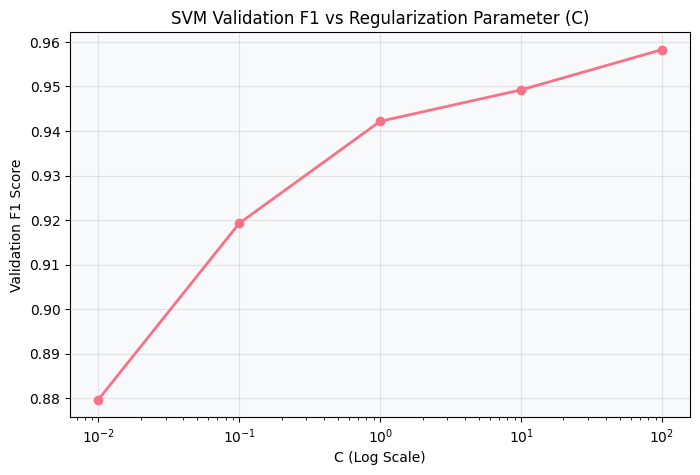


Support Vector Machine (RBF) Results


,Dataset,Validation Accuracy,Validation F1,Validation AUC,Test Accuracy,Test F1,Test AUC
0,Original Features,0.941197,0.942177,0.982734,0.933425,0.934995,0.978975
1,Reduced Features,0.922172,0.924674,0.971852,0.920662,0.923740,0.968953


In [21]:
# ============================================================
# SUPPORT VECTOR MACHINE (RBF) ANALYSIS
# ============================================================

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# ORIGINAL FEATURES MODEL
# ============================================================

svm_original = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=42
)

svm_original.fit(
    X_train_sc,
    y_train
)

# Validation predictions
val_pred_original = svm_original.predict(X_val_sc)

# Test predictions
test_pred_original = svm_original.predict(X_test_sc)

# Prediction probabilities
val_prob_original = svm_original.predict_proba(X_val_sc)[:,1]
test_prob_original = svm_original.predict_proba(X_test_sc)[:,1]

# ============================================================
# REDUCED FEATURES MODEL
# ============================================================

svm_reduced = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=42
)

svm_reduced.fit(
    X_train_sc_red,
    y_train_red
)

# Validation predictions
val_pred_reduced = svm_reduced.predict(X_val_sc_red)

# Test predictions
test_pred_reduced = svm_reduced.predict(X_test_sc_red)

# Prediction probabilities
val_prob_reduced = svm_reduced.predict_proba(X_val_sc_red)[:,1]
test_prob_reduced = svm_reduced.predict_proba(X_test_sc_red)[:,1]

# ============================================================
# TRAINING / COMPLEXITY CURVE
# ============================================================

C_values = [0.01, 0.1, 1, 10, 100]

val_f1_scores = []

for c in C_values:

    model = SVC(
        kernel='rbf',
        C=c,
        probability=True,
        random_state=42
    )

    model.fit(
        X_train_sc,
        y_train
    )

    pred = model.predict(X_val_sc)

    val_f1_scores.append(
        f1_score(y_val, pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    C_values,
    val_f1_scores,
    marker='o',
    linewidth=2
)

plt.xscale("log")

plt.title(
    'SVM Validation F1 vs Regularization Parameter (C)'
)

plt.xlabel('C (Log Scale)')
plt.ylabel('Validation F1 Score')

plt.grid(True)

plt.show()

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison_svm = pd.DataFrame({

    'Dataset': [
        'Original Features',
        'Reduced Features'
    ],

    'Validation Accuracy': [
        accuracy_score(y_val, val_pred_original),
        accuracy_score(y_val_red, val_pred_reduced)
    ],

    'Validation F1': [
        f1_score(y_val, val_pred_original),
        f1_score(y_val_red, val_pred_reduced)
    ],

    'Validation AUC': [
        roc_auc_score(y_val, val_prob_original),
        roc_auc_score(y_val_red, val_prob_reduced)
    ],

    'Test Accuracy': [
        accuracy_score(y_test, test_pred_original),
        accuracy_score(y_test_red, test_pred_reduced)
    ],

    'Test F1': [
        f1_score(y_test, test_pred_original),
        f1_score(y_test_red, test_pred_reduced)
    ],

    'Test AUC': [
        roc_auc_score(y_test, test_prob_original),
        roc_auc_score(y_test_red, test_prob_reduced)
    ]
})

print("\nSupport Vector Machine (RBF) Results")
display(comparison_svm)

# Save results for final comparison

svm_result = {
    "Model": "SVM (RBF)",
    "Accuracy": accuracy_score(y_test, test_pred_original),
    "Precision": precision_score(y_test, test_pred_original),
    "Recall": recall_score(y_test, test_pred_original),
    "F1": f1_score(y_test, test_pred_original),
    "AUC": roc_auc_score(y_test, test_prob_original)
}

In [22]:
# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

results = pd.DataFrame([

    lr_result,
    dt_result,
    knn_result,
    rf_result,
    gb_result,
    svm_result

])

results = results.sort_values(
    by="F1",
    ascending=False
)

print("Final Model Comparison")
display(results)

Final Model Comparison


,Model,Accuracy,Precision,Recall,F1,AUC
3,Random Forest,0.974819,0.961126,0.989648,0.975179,0.997699
1,Decision Tree,0.962056,0.955133,0.969634,0.962329,0.962058
2,KNN,0.955157,0.927414,0.987578,0.956551,0.981935
4,Gradient Boosting,0.946188,0.927297,0.968254,0.947333,0.987038
5,SVM (RBF),0.933425,0.913158,0.957902,0.934995,0.978975
0,Logistic Regression,0.835805,0.840448,0.828847,0.834607,0.915351


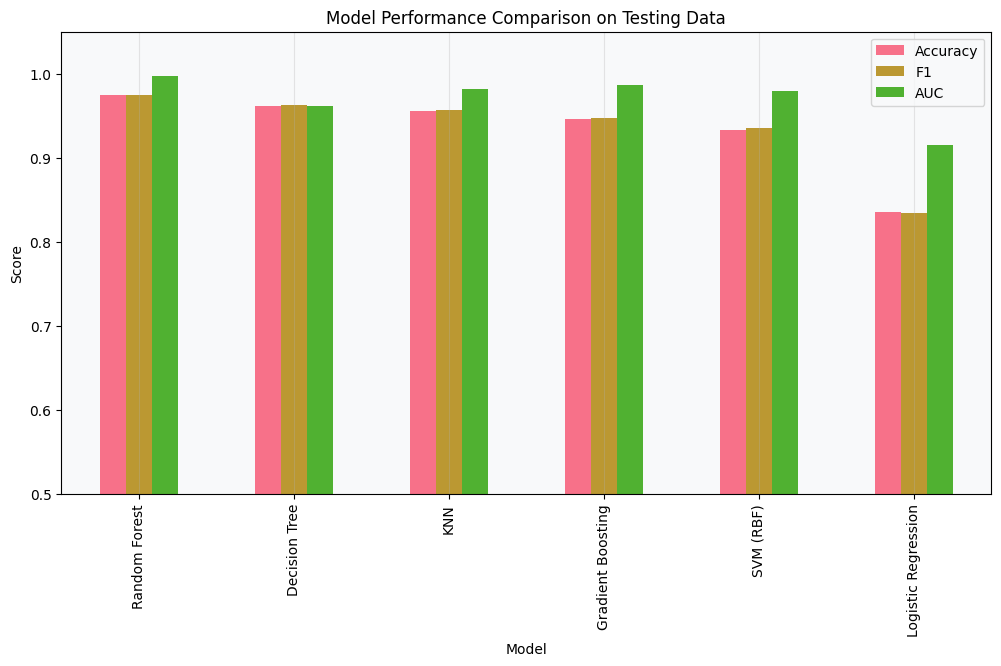

In [23]:
metrics = results.set_index("Model")[[
    "Accuracy",
    "F1",
    "AUC"
]]

metrics.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison on Testing Data")

plt.ylabel("Score")

plt.ylim(0.5,1.05)

plt.grid(axis="y")

plt.show()

In [24]:
best_model = results.iloc[0]

print("="*50)
print("BEST MACHINE LEARNING MODEL")
print("="*50)

print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']:.4f}")
print(f"Precision : {best_model['Precision']:.4f}")
print(f"Recall    : {best_model['Recall']:.4f}")
print(f"F1 Score  : {best_model['F1']:.4f}")
print(f"AUC       : {best_model['AUC']:.4f}")

BEST MACHINE LEARNING MODEL
Model     : Random Forest
Accuracy  : 0.9748
Precision : 0.9611
Recall    : 0.9896
F1 Score  : 0.9752
AUC       : 0.9977
